In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
GEOMETRY_FILE = "/groups/pheno/inar/icecube_kaggle/sensor_geometry.csv"
sensor_geometry_df = pd.read_csv(GEOMETRY_FILE, index_col='sensor_id')

In [3]:
from polarbert.pretraining import get_dataloaders
from polarbert.time_embedding import IceCubeTimeEmbedding
from polarbert.config import PolarBertConfig

config_file = "/groups/pheno/inar/PolarBERT/configs/polarbert_new.yaml"
config = PolarBertConfig.from_yaml(config_file)

config_dict = config.to_dict()
config_dict["training"]["per_device_batch_size"] = 32
train_loader_k, val_loader_k = get_dataloaders(config_dict, dataset_type='kaggle')

Loading configuration from: /groups/pheno/inar/PolarBERT/configs/polarbert_new.yaml
Validating configuration...
Configuration validation passed (with potential warnings).


/lustre/hpc/pheno/inar/PolarBERT/src/polarbert/config.py:154: UserWarning: In ModelConfig: Unexpected keys found in config dictionary and will be ignored: {'dom_embed_dim'}
  warnings.warn(
/lustre/hpc/pheno/inar/PolarBERT/src/polarbert/config.py:457: UserWarning: training.final_div_factor (0.133333) < 1.0. Usually >= 1.0 (e.g., 1e4) for OneCycleLR.
  warnings.warn(f"training.final_div_factor ({train_cfg.final_div_factor}) < 1.0. "


In [4]:
config_p = config_dict.copy()
config_p["data"]["val_events"] = 1000
config_p["data"]["train_dir"] = "/groups/pheno/inar/orca_prometheus/memmaped_orca"
del config_p["data"]["val_dir"]

In [5]:
GEOMETRY_FILE1 = "/groups/pheno/inar/orca_prometheus/orca_sensor_geometry.csv"
sensor_geometry_df_orca = pd.read_csv(GEOMETRY_FILE1, index_col='sensor_id')

In [6]:
train_loader_p, val_loader_p = get_dataloaders(config_p, dataset_type='prometheus')

In [7]:
len(train_loader_k), len(val_loader_k)

(3124999, 6249)

In [8]:
len(train_loader_p), len(val_loader_p)

(12024, 30)

In [9]:
import numpy as np
import pandas as pd
import torch
import warnings
# Use tqdm.notebook if in a Jupyter environment, otherwise standard tqdm
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

# Make sure these constants are defined in your notebook scope
SPEED_OF_LIGHT_M_NS = 0.299792458
ZERO_TOLERANCE = 1e-9

# --- Updated Analysis Function ---

def analyze_light_cone(dataloader, geometry_df, max_events=None):
    """
    Analyzes events from a dataloader to check for light cone causality.

    Args:
        dataloader: PyTorch DataLoader yielding batches.
                      Expected batch format: ((x, l), targets)
                      where targets = (y, c) or None.
                      y: tensor (batch, 2) [azimuth, zenith] or None.
                      c: tensor (batch,) [total_charge] or None.
        geometry_df: Pandas DataFrame with sensor geometry indexed by sensor_id.
        max_events (int, optional): Maximum number of events to process. Defaults to None (all).

    Returns:
        pandas.DataFrame: DataFrame containing analysis results for each event
                          with valid comparisons. Columns include:
                          num_non_aux_pulses, num_comparisons, inside_count,
                          outside_count, fraction_inside, fraction_outside,
                          azimuth, zenith, total_charge.
    """
    results = []
    events_processed_counter = 0 # Total events iterated through from loader
    valid_events_analyzed = 0  # Events successfully analyzed with comparisons

    print(f"Starting light cone analysis...")
    # Try to get dataloader length for tqdm total, may fail for IterableDataset
    try:
        # Heuristic: If max_events is set, estimate batches needed
        # Assumes batch_size is accessible, might need adjustment
        bs = getattr(dataloader, 'batch_size', None) or getattr(getattr(dataloader, 'sampler', None), 'batch_size', 32) # Estimate batch size
        if max_events and bs:
            total_batches = math.ceil(max_events / bs)
        else:
            total_batches = len(dataloader)
    except TypeError:
        total_batches = None # Unknown length

    pbar = tqdm(dataloader, total=total_batches, desc="Processing Batches", leave=True)
    for batch in pbar:
        # Check if we should stop *before* processing the batch if max_events is hit
        if max_events is not None and events_processed_counter >= max_events:
             break

        try:
             (x_batch_torch, l_batch_torch), targets = batch
        except ValueError as e:
             warnings.warn(f"Error unpacking batch: {e}. Skipping batch.")
             continue # Skip malformed batch

        # Ensure tensors are on CPU before converting to numpy
        x_batch = x_batch_torch.cpu().numpy()
        l_batch = l_batch_torch.cpu().numpy() # Potential source of non-int if dtype changed
        batch_size = x_batch.shape[0]

        # Extract targets (same logic as before)
        y_batch, c_batch = None, None
        if targets is not None:
            try:
                y_tensor, c_tensor = targets # Assuming tuple (y, c)
                if y_tensor is not None:
                    y_batch = y_tensor.cpu().numpy()
                    if y_batch.ndim != 2 or y_batch.shape[1] != 2:
                        warnings.warn(f"Batch {pbar.n}: Unexpected y shape: {y_batch.shape}. Targets ignored.")
                        y_batch = None
                if c_tensor is not None:
                    c_batch = c_tensor.cpu().numpy()
                    if c_batch.ndim != 1:
                         warnings.warn(f"Batch {pbar.n}: Unexpected c shape: {c_batch.shape}. Charges ignored.")
                         c_batch = None
            except Exception as e:
                 warnings.warn(f"Batch {pbar.n}: Error processing targets: {e}. Targets ignored.")
                 y_batch, c_batch = None, None


        for event_idx in range(batch_size):
            current_event_global_idx = events_processed_counter # For tracking purposes

            # Check max_events limit *before* heavy processing within the event
            if max_events is not None and current_event_global_idx >= max_events:
                 break # Exit inner loop

            events_processed_counter += 1 # Increment only when starting to process an event

            # Get event targets
            azimuth, zenith, total_charge = np.nan, np.nan, np.nan
            if y_batch is not None:
                 try: azimuth, zenith = y_batch[event_idx, 0], y_batch[event_idx, 1]
                 except IndexError: pass
            if c_batch is not None:
                 try: total_charge = c_batch[event_idx]
                 except IndexError: pass

            event_features = x_batch[event_idx]
            event_length_raw = l_batch[event_idx] # Get the raw length value

            # *** FIX: Ensure event_length is integer for slicing ***
            try:
                 event_length = int(event_length_raw)
                 if event_length < 0: # Handle negative lengths just in case
                      raise ValueError("Negative length")
            except (ValueError, TypeError): # Catch potential conversion errors or if it's not number-like
                 warnings.warn(f"Event index ~{current_event_global_idx}: Invalid length value ({event_length_raw}). Skipping event.")
                 continue # Skip event if length cannot be converted to int

            if event_length == 0: # Skip events with zero length
                 continue

            # Slice using the validated integer length
            valid_pulses = event_features[:event_length]

            # --- Rest of the core analysis logic ---
            raw_times = valid_pulses[:, 0] * 3e4 + 1e4
            raw_aux = valid_pulses[:, 2] + 0.5
            raw_sensor_ids = (valid_pulses[:, 3] - 1).astype(int) # Ensure sensor IDs are int
            non_aux_mask = (raw_aux == 0)
            non_aux_pulses_indices = np.where(non_aux_mask)[0]
            num_non_aux = len(non_aux_pulses_indices)
            if num_non_aux < 2: continue # Need at least 2 non-aux pulses

            non_aux_times = raw_times[non_aux_mask]
            first_pulse_relative_idx = np.argmin(non_aux_times)
            first_pulse_event_idx = non_aux_pulses_indices[first_pulse_relative_idx]
            t0 = raw_times[first_pulse_event_idx]
            sensor0_id = raw_sensor_ids[first_pulse_event_idx]

            try: coords0 = geometry_df.loc[sensor0_id, ['x', 'y', 'z']].values
            except KeyError:
                # warnings.warn(f"Event index ~{current_event_global_idx}: Sensor ID {sensor0_id} not found for first pulse. Skipping event.")
                continue # Skip event if first pulse sensor not found

            inside_count, outside_count, num_compared = 0, 0, 0
            for other_pulse_relative_idx in range(num_non_aux):
                if other_pulse_relative_idx == first_pulse_relative_idx: continue
                other_pulse_event_idx = non_aux_pulses_indices[other_pulse_relative_idx]
                ti, sensori_id = raw_times[other_pulse_event_idx], raw_sensor_ids[other_pulse_event_idx]
                try: coordsi = geometry_df.loc[sensori_id, ['x', 'y', 'z']].values
                except KeyError:
                    # warnings.warn(f"Event index ~{current_event_global_idx}: Sensor ID {sensori_id} not found for comparison pulse. Skipping comparison.")
                    continue # Skip comparison if sensor not found
                num_compared += 1
                delta_t, delta_coords = ti - t0, coordsi - coords0
                delta_d_sq = np.sum(delta_coords**2)
                s_squared = (SPEED_OF_LIGHT_M_NS * delta_t)**2 - delta_d_sq
                is_causal = (s_squared >= -ZERO_TOLERANCE) and (delta_t >= -ZERO_TOLERANCE)
                if is_causal: inside_count += 1
                else: outside_count += 1

            # --- Store results only if comparisons were made ---
            if num_compared > 0:
                fraction_inside = inside_count / num_compared
                fraction_outside = outside_count / num_compared
                result_summary = {
                    "num_non_aux_pulses": num_non_aux, "num_comparisons": num_compared,
                    "inside_count": inside_count, "outside_count": outside_count,
                    "fraction_inside": fraction_inside, "fraction_outside": fraction_outside,
                    "azimuth": azimuth, "zenith": zenith, "total_charge": total_charge,
                }
                results.append(result_summary)
                valid_events_analyzed += 1 # Increment count of successful analyses
        # --- End of event loop ---

        # Update progress bar postfix after processing the batch
        pbar.set_postfix(Processed=f'{events_processed_counter}/{max_events if max_events is not None else "?"}',
                         Analyzed=f'{valid_events_analyzed}', refresh=True)

        # Check max_events limit *after* processing the batch's events
        # This ensures we stop exactly after hitting the limit (or slightly over)
        if max_events is not None and events_processed_counter >= max_events:
             break # Exit outer loop
    # --- End of batch loop ---
    pbar.close() # Ensure tqdm bar is closed cleanly

    print(f"\nFinished iterating. Processed {events_processed_counter} events attempted.")
    print(f"Returning results for {len(results)} events with valid comparisons.")
    if not results:
        return pd.DataFrame() # Return empty DataFrame if no results
    return pd.DataFrame(results)



In [10]:
import matplotlib.pyplot as plt
def plot_light_cone_analysis(results_df):
    """
    Generates plots summarizing the light cone analysis results.

    Args:
        results_df (pandas.DataFrame): DataFrame returned by analyze_light_cone.
    """
    if results_df.empty:
        print("Results DataFrame is empty. No plots generated.")
        return

    print("\n--- Generating Plots ---")

    # --- Plot 1: Histogram of Fraction Inside ---
    plt.figure(figsize=(10, 6))
    plt.hist(results_df['fraction_inside'], bins=50, edgecolor='black', alpha=0.7)
    plt.title('Distribution of Fraction of Pulses Inside Light Cone')
    plt.xlabel('Fraction Inside Light Cone')
    plt.ylabel('Number of Events')
    plt.grid(axis='y', alpha=0.75)
    plt.tight_layout()
    plt.show()

    # --- Plot 2: Average Fraction Inside vs. Number of Non-Aux Pulses ---
    # Calculate mean fraction for each number of non-aux pulses
    # Also get counts to understand reliability (optional to plot counts)
    grouped = results_df.groupby('num_non_aux_pulses')['fraction_inside']
    avg_fraction_by_pulses = grouped.mean()
    counts_by_pulses = grouped.size()

    # Filter out groups with very few events for a potentially cleaner plot
    min_events_per_group = 5 # Adjust as needed
    reliable_pulses = counts_by_pulses[counts_by_pulses >= min_events_per_group].index
    avg_fraction_filtered = avg_fraction_by_pulses.loc[reliable_pulses]

    plt.figure(figsize=(12, 7))
    # Plot average line
    plt.plot(avg_fraction_filtered.index, avg_fraction_filtered.values, marker='o', linestyle='-', markersize=5, label=f'Average (Groups >= {min_events_per_group} events)')
    # Optional: Scatter plot of all points underneath
    # plt.scatter(results_df['num_non_aux_pulses'], results_df['fraction_inside'], alpha=0.05, s=5, label='Individual Events', color='lightblue')

    plt.title('Average Fraction Inside Light Cone vs. Number of Non-Aux Pulses')
    plt.xlabel('Number of Non-Auxiliary Pulses in Event')
    plt.ylabel('Average Fraction Inside Light Cone')
    plt.ylim(0, 1.05)
    # Optional: Set x-axis limits if needed, e.g., plt.xlim(0, max(results_df['num_non_aux_pulses']) * 1.05)
    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.show()


    # --- Plot 3: Fraction Inside vs. Total Charge ---
    # Filter out events where total_charge is missing or non-positive for log scale
    results_with_charge = results_df.dropna(subset=['total_charge'])
    results_with_charge = results_with_charge[results_with_charge['total_charge'] > 0]

    if not results_with_charge.empty:
        print(f"\nGenerating charge plot using {len(results_with_charge)} events with valid charge data.")
        plt.figure(figsize=(10, 6))
        plt.scatter(results_with_charge['total_charge'], results_with_charge['fraction_inside'], alpha=0.2, s=10)
        plt.xscale('log') # Use log scale for charge
        plt.title('Fraction Inside Light Cone vs. Total Event Charge')
        plt.xlabel('Total Event Charge (log scale)') # Indicate log scale
        plt.ylabel('Fraction Inside Light Cone')
        plt.ylim(0, 1.05)
        plt.grid(True, alpha=0.5)
        plt.tight_layout()
        plt.show()
    else:
        print("\nNo events with valid positive charge data found to generate charge plot.")


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# Helper function for formatting numbers (optional, but helps)
def format_num(value, precision=3, is_int=False, use_exp_threshold=1e5):
    """Formats numbers for printing, using exponential notation for large/small floats."""
    if pd.isna(value):
        return "NaN"
    try:
        val = float(value)
        if is_int:
            return f"{int(val):,}"
        elif abs(val) > use_exp_threshold or (abs(val) < 10**(-precision) and val != 0):
             return f"{val:.{precision}e}"
        else:
            return f"{val:.{precision}f}"
    except (ValueError, TypeError):
        return str(value)


def compare_light_cone_analyses(df1, df2, label1="Dataset 1", label2="Dataset 2", min_events_per_group=10):
    """
    Compares light cone analysis results from two datasets.

    Generates comparative plots for average fraction inside vs. number of
    non-aux pulses and vs. total event charge, a scatter plot of charge vs num pulses,
    and prints detailed summary statistics.

    Args:
        df1 (pd.DataFrame): Results DataFrame for the first dataset.
        df2 (pd.DataFrame): Results DataFrame for the second dataset.
        label1 (str): Label for the first dataset.
        label2 (str): Label for the second dataset.
        min_events_per_group (int): Minimum number of events required in a group
                                     (for num_pulses or charge bin) to be
                                     included in the average plots.
    """
    print(f"--- Comparing Light Cone Analysis: '{label1}' vs '{label2}' ---")

    # --- Input Validation ---
    required_cols = ['num_non_aux_pulses', 'fraction_inside', 'total_charge', 'num_comparisons']
    if df1.empty or df2.empty:
        print("One or both DataFrames are empty. Cannot perform comparison.")
        return
    if not all(col in df1.columns for col in required_cols) or \
       not all(col in df2.columns for col in required_cols):
        print(f"Error: DataFrames must contain columns: {required_cols}")
        return

    # --- Calculate and Print Summary Statistics ---
    # (Code for calculating and printing stats remains the same as previous version)
    datasets = {label1: df1, label2: df2}
    summary_stats = {}
    # ... (calculation logic identical to previous version) ...
    for label, df in datasets.items():
        stats = {}
        n_events = len(df)
        stats["Num Events Analyzed"] = n_events
        if n_events > 0:
            stats["Mean Fraction Inside"] = df['fraction_inside'].mean()
            stats["Median Fraction Inside"] = df['fraction_inside'].median()
            stats["Std Dev Fraction Inside"] = df['fraction_inside'].std()
            q_frac = df['fraction_inside'].quantile([0.25, 0.75])
            stats["IQR Fraction Inside"] = (q_frac[0.25], q_frac[0.75])
            stats["Min Fraction Inside"] = df['fraction_inside'].min()
            stats["Max Fraction Inside"] = df['fraction_inside'].max()
            stats["% Events < 100% Inside"] = (df['fraction_inside'] < (1.0 - 1e-9)).mean() * 100
            stats["Mean Non-Aux Pulses"] = df['num_non_aux_pulses'].mean()
            stats["Median Non-Aux Pulses"] = df['num_non_aux_pulses'].median()
            stats["Std Dev Non-Aux Pulses"] = df['num_non_aux_pulses'].std()
            q_pulses = df['num_non_aux_pulses'].quantile([0.25, 0.75])
            stats["IQR Non-Aux Pulses"] = (q_pulses[0.25], q_pulses[0.75])
            stats["Min Non-Aux Pulses"] = df['num_non_aux_pulses'].min()
            stats["Max Non-Aux Pulses"] = df['num_non_aux_pulses'].max()
            charge_valid = df['total_charge'].dropna()
            stats["% Events with Charge"] = len(charge_valid) / n_events * 100 if n_events > 0 else 0
            if not charge_valid.empty:
                 stats["Mean Total Charge"] = charge_valid.mean()
                 stats["Median Total Charge"] = charge_valid.median()
                 stats["Std Dev Total Charge"] = charge_valid.std()
                 q_charge = charge_valid.quantile([0.25, 0.75])
                 stats["IQR Total Charge"] = (q_charge[0.25], q_charge[0.75])
                 stats["Min Total Charge"] = charge_valid.min()
                 stats["Max Total Charge"] = charge_valid.max()
            else: stats["Mean Total Charge"] = np.nan
            stats["Mean Num Comparisons"] = df['num_comparisons'].mean()
            stats["Median Num Comparisons"] = df['num_comparisons'].median()
            stats["Min Num Comparisons"] = df['num_comparisons'].min()
            stats["Max Num Comparisons"] = df['num_comparisons'].max()
        summary_stats[label] = stats

    print("\n" + "="*25 + " Summary Statistics " + "="*25)
    for label, stats in summary_stats.items():
        # ... (pretty printing logic identical to previous version) ...
        print(f"\n--- {label} ---")
        if not stats or stats["Num Events Analyzed"] == 0: print(" (No data to analyze)"); continue
        print(f" Events Analyzed:             {format_num(stats.get('Num Events Analyzed'), is_int=True)}")
        print(" Fraction Inside Light Cone:")
        print(f"  Mean / Median / Std Dev:   {format_num(stats.get('Mean Fraction Inside'), 3)} / {format_num(stats.get('Median Fraction Inside'), 3)} / {format_num(stats.get('Std Dev Fraction Inside'), 3)}")
        iqr_frac = stats.get('IQR Fraction Inside', (np.nan, np.nan)); print(f"  Min / Max / IQR (25-75%):  {format_num(stats.get('Min Fraction Inside'), 3)} / {format_num(stats.get('Max Fraction Inside'), 3)} / ({format_num(iqr_frac[0], 3)} - {format_num(iqr_frac[1], 3)})")
        print(f"  % Events < 100% Inside:    {format_num(stats.get('% Events w/ <100% Inside'), 1)}%")
        print(" Non-Auxiliary Pulses:")
        print(f"  Mean / Median / Std Dev:   {format_num(stats.get('Mean Non-Aux Pulses'), 1)} / {format_num(stats.get('Median Non-Aux Pulses'), 1)} / {format_num(stats.get('Std Dev Non-Aux Pulses'), 1)}")
        iqr_pulses = stats.get('IQR Non-Aux Pulses', (np.nan, np.nan)); print(f"  Min / Max / IQR (25-75%):  {format_num(stats.get('Min Non-Aux Pulses'), 0, is_int=True)} / {format_num(stats.get('Max Non-Aux Pulses'), 0, is_int=True)} / ({format_num(iqr_pulses[0], 0, is_int=True)} - {format_num(iqr_pulses[1], 0, is_int=True)})")
        print(" Total Charge (p.e.):"); print(f"  % Events with Charge Data: {format_num(stats.get('% Events with Charge'), 1)}%")
        if not pd.isna(stats.get('Mean Total Charge')):
            print(f"  Mean / Median / Std Dev:   {format_num(stats.get('Mean Total Charge'), 1)} / {format_num(stats.get('Median Total Charge'), 1)} / {format_num(stats.get('Std Dev Total Charge'), 1)}")
            iqr_charge = stats.get('IQR Total Charge', (np.nan, np.nan)); print(f"  Min / Max / IQR (25-75%):  {format_num(stats.get('Min Total Charge'), 1)} / {format_num(stats.get('Max Total Charge'), 1)} / ({format_num(iqr_charge[0], 1)} - {format_num(iqr_charge[1], 1)})")
        else: print("  (No valid charge data for stats)")
        print(" Event Comparisons:"); print(f"  Mean / Median:             {format_num(stats.get('Mean Num Comparisons'), 1)} / {format_num(stats.get('Median Num Comparisons'), 1)}")
        print(f"  Min / Max:                 {format_num(stats.get('Min Num Comparisons'), 0, is_int=True)} / {format_num(stats.get('Max Num Comparisons'), 0, is_int=True)}")
    print("="*70)


    # --- Plot 1: Average Fraction vs. Number of Non-Aux Pulses ---
    print(f"\nGenerating plot: Average Fraction vs. Num Pulses (min {min_events_per_group} events/group)...")
    # ... (plotting code remains the same) ...
    grouped1 = df1.groupby('num_non_aux_pulses')['fraction_inside']; avg_frac1 = grouped1.mean(); counts1 = grouped1.size(); reliable_pulses1 = counts1[counts1 >= min_events_per_group].index; avg_frac_filtered1 = avg_frac1.loc[reliable_pulses1]
    grouped2 = df2.groupby('num_non_aux_pulses')['fraction_inside']; avg_frac2 = grouped2.mean(); counts2 = grouped2.size(); reliable_pulses2 = counts2[counts2 >= min_events_per_group].index; avg_frac_filtered2 = avg_frac2.loc[reliable_pulses2]
    plt.figure(figsize=(12, 7))
    if not avg_frac_filtered1.empty: plt.plot(avg_frac_filtered1.index, avg_frac_filtered1.values, marker='o', linestyle='-', markersize=4, label=f'{label1}')
    if not avg_frac_filtered2.empty: plt.plot(avg_frac_filtered2.index, avg_frac_filtered2.values, marker='x', linestyle='--', markersize=5, label=f'{label2}')
    plt.title('Average Fraction Inside Light Cone vs. Number of Non-Aux Pulses'); plt.xlabel('Number of Non-Auxiliary Pulses in Event'); plt.ylabel('Average Fraction Inside Light Cone'); plt.ylim(0, 1.05); plt.legend(); plt.grid(True, alpha=0.5); plt.tight_layout(); plt.show()


    # --- Plot 2: Average Fraction vs. Total Charge ---
    print(f"\nGenerating plot: Average Fraction vs. Total Charge (min {min_events_per_group} events/bin)...")
    # ... (plotting code remains the same, including observed=True fix) ...
    df1_charge = df1.dropna(subset=['total_charge']); df1_charge = df1_charge[df1_charge['total_charge'] > 0]
    df2_charge = df2.dropna(subset=['total_charge']); df2_charge = df2_charge[df2_charge['total_charge'] > 0]
    if df1_charge.empty and df2_charge.empty: print("No valid positive charge data found in either dataset. Skipping charge plot.")
    else:
        min_charge = min(df1_charge['total_charge'].min() if not df1_charge.empty else np.inf, df2_charge['total_charge'].min() if not df2_charge.empty else np.inf)
        max_charge = max(df1_charge['total_charge'].max() if not df1_charge.empty else -np.inf, df2_charge['total_charge'].max() if not df2_charge.empty else -np.inf)
        if np.isinf(min_charge) or np.isinf(max_charge) or min_charge <= 0 or max_charge <= 0: print("Could not determine valid charge range for bins. Skipping charge plot.")
        else:
            num_bins = 30; bins = np.logspace(np.log10(min_charge), np.log10(max_charge + 1e-9), num_bins + 1)
            avg_frac_charge_filtered1 = pd.Series(dtype=float); plot_centers1 = []
            if not df1_charge.empty:
                df1_charge['charge_bin'] = pd.cut(df1_charge['total_charge'], bins=bins, right=False, labels=False, include_lowest=True)
                grouped_charge1 = df1_charge.groupby('charge_bin', observed=True)['fraction_inside']; avg_frac_charge1 = grouped_charge1.mean(); counts_charge1 = grouped_charge1.size(); avg_frac_charge_filtered1 = avg_frac_charge1[counts_charge1 >= min_events_per_group]
                bin_centers_all = np.sqrt(bins[:-1] * bins[1:]); plot_centers1 = bin_centers_all[avg_frac_charge_filtered1.index]
            avg_frac_charge_filtered2 = pd.Series(dtype=float); plot_centers2 = []
            if not df2_charge.empty:
                df2_charge['charge_bin'] = pd.cut(df2_charge['total_charge'], bins=bins, right=False, labels=False, include_lowest=True)
                grouped_charge2 = df2_charge.groupby('charge_bin', observed=True)['fraction_inside']; avg_frac_charge2 = grouped_charge2.mean(); counts_charge2 = grouped_charge2.size(); avg_frac_charge_filtered2 = avg_frac_charge2[counts_charge2 >= min_events_per_group]
                bin_centers_all = np.sqrt(bins[:-1] * bins[1:]); plot_centers2 = bin_centers_all[avg_frac_charge_filtered2.index]
            plt.figure(figsize=(12, 7))
            if not avg_frac_charge_filtered1.empty: plt.plot(plot_centers1, avg_frac_charge_filtered1.values, marker='o', linestyle='-', markersize=4, label=f'{label1}')
            if not avg_frac_charge_filtered2.empty: plt.plot(plot_centers2, avg_frac_charge_filtered2.values, marker='x', linestyle='--', markersize=5, label=f'{label2}')
            plt.xscale('log'); plt.title('Average Fraction Inside Light Cone vs. Total Event Charge'); plt.xlabel('Total Event Charge (p.e.) - Log Scale'); plt.ylabel('Average Fraction Inside Light Cone'); plt.ylim(0, 1.05)
            if len(plot_centers1) > 0 or len(plot_centers2) > 0: plt.legend()
            plt.grid(True, which='both', alpha=0.5); plt.tight_layout(); plt.show()


    # --- Plot 3: Total Charge vs. Number of Non-Aux Pulses ---
    print("\nGenerating plot: Total Charge vs. Number of Non-Aux Pulses...")

    # Reuse filtered data from Plot 2 (df1_charge, df2_charge)
    if df1_charge.empty and df2_charge.empty:
         print("No valid positive charge data found in either dataset. Skipping Charge vs Pulses plot.")
    else:
        plt.figure(figsize=(12, 7))

        # Plot scatter for df1
        if not df1_charge.empty:
            plt.scatter(
                df1_charge['num_non_aux_pulses'],
                df1_charge['total_charge'],
                alpha=0.2,  # Low alpha for overplotting
                s=5,        # Small marker size
                label=label1,
                marker='o'  # Circle marker for dataset 1
            )

        # Plot scatter for df2
        if not df2_charge.empty:
            plt.scatter(
                df2_charge['num_non_aux_pulses'],
                df2_charge['total_charge'],
                alpha=0.2,  # Low alpha for overplotting
                s=5,        # Small marker size
                label=label2,
                marker='x'  # Cross marker for dataset 2
            )

        plt.yscale('log') # Log scale for charge is essential here
        plt.title('Total Event Charge vs. Number of Non-Auxiliary Pulses')
        plt.xlabel('Number of Non-Auxiliary Pulses in Event')
        plt.ylabel('Total Event Charge (p.e.) - Log Scale')
        # Optional: Set xlim if needed, e.g., plt.xlim(left=0)
        if not df1_charge.empty or not df2_charge.empty:
            plt.legend() # Add legend to distinguish datasets
        plt.grid(True, which='both', alpha=0.5) # Grid lines for both axes
        plt.tight_layout()
        plt.show()

    print(f"\n--- Comparison Complete ---")


# --- Example Usage ---
# compare_light_cone_analyses(
#     analysis_results_df_p,
#     analysis_results_df_k,
#     label1="Prometheus",
#     label2="Kaggle",
#     min_events_per_group=10
# )

In [12]:
MAX_EVENTS = 2000

In [13]:
analysis_results_df_k = analyze_light_cone(train_loader_k, sensor_geometry_df, max_events=MAX_EVENTS)


Starting light cone analysis...


Processing Batches:   0%|          | 0/63 [00:00<?, ?it/s]


Finished iterating. Processed 2000 events attempted.
Returning results for 2000 events with valid comparisons.


In [14]:
analysis_results_df_p = analyze_light_cone(train_loader_p, sensor_geometry_df_orca, max_events=MAX_EVENTS)

Starting light cone analysis...


Processing Batches:   0%|          | 0/63 [00:00<?, ?it/s]


Finished iterating. Processed 2000 events attempted.
Returning results for 2000 events with valid comparisons.


--- Comparing Light Cone Analysis: 'Prometheus no noise' vs 'Kaggle' ---

========================= Summary Statistics =========================

--- Prometheus no noise ---
 Events Analyzed:             2,000
 Fraction Inside Light Cone:
  Mean / Median / Std Dev:   0.743 / 0.786 / 0.188
  Min / Max / IQR (25-75%):  0.000 / 1.000 / (0.667 - 0.865)
  % Events < 100% Inside:    NaN%
 Non-Auxiliary Pulses:
  Mean / Median / Std Dev:   102.2 / 127.0 / 40.2
  Min / Max / IQR (25-75%):  4 / 127 / (79 - 127)
 Total Charge (p.e.):
  % Events with Charge Data: 100.0%
  Mean / Median / Std Dev:   12149.4 / 4412.5 / 46616.7
  Min / Max / IQR (25-75%):  3676.1 / 8.5e+05 / (3969.1 - 6566.4)
 Event Comparisons:
  Mean / Median:             101.2 / 126.0
  Min / Max:                 3 / 126

--- Kaggle ---
 Events Analyzed:             2,000
 Fraction Inside Light Cone:
  Mean / Median / Std Dev:   0.663 / 0.706 / 0.248
  Min / Max / IQR (25-75%):  0.000 / 1.000 / (0.500 - 0.862)
  % Events < 100% I

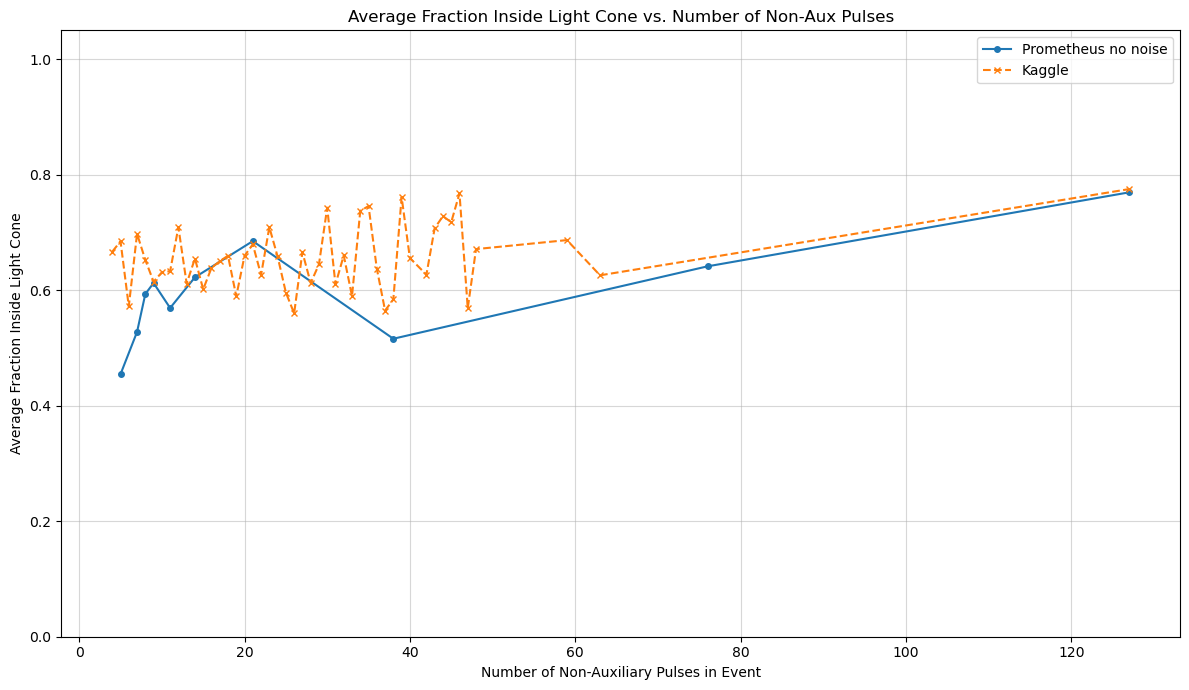


Generating plot: Average Fraction vs. Total Charge (min 10 events/bin)...


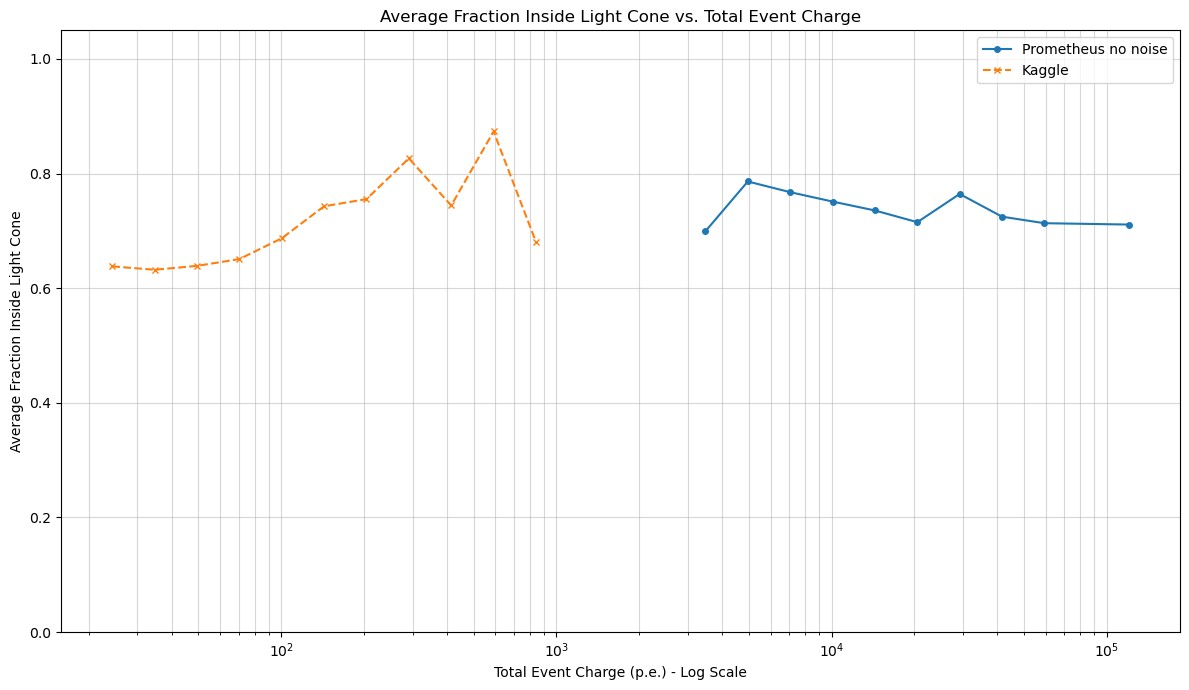


Generating plot: Total Charge vs. Number of Non-Aux Pulses...


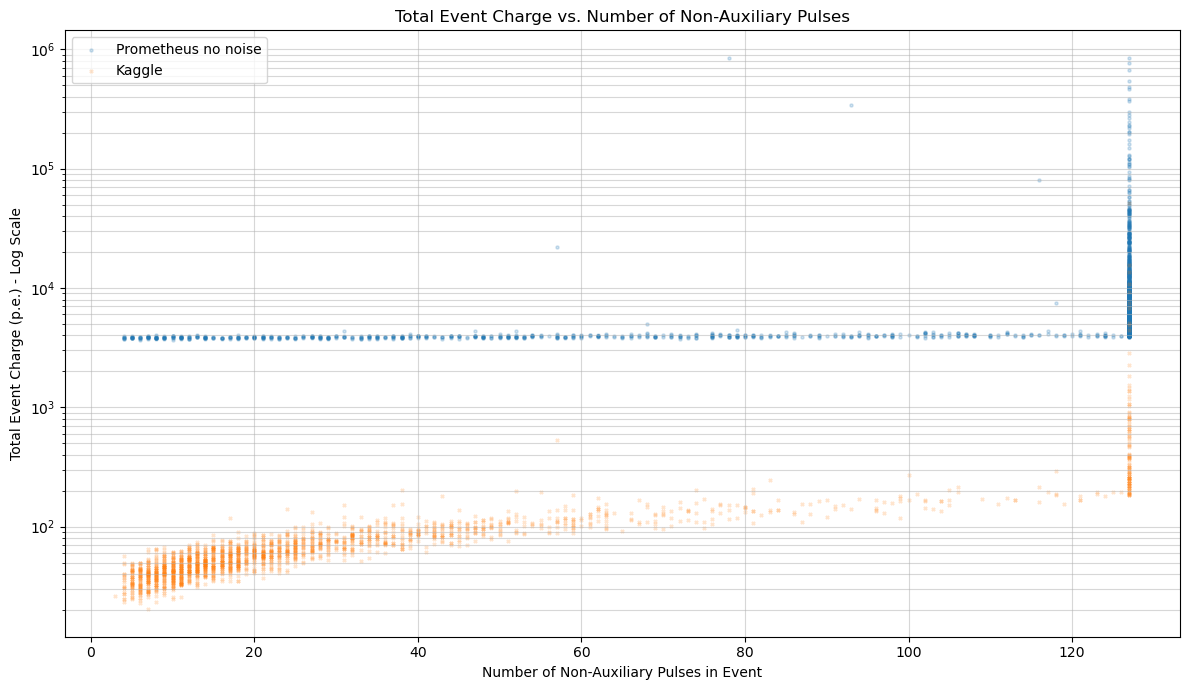


--- Comparison Complete ---


In [15]:

# Example Usage (in your notebook):
# Assuming you have analysis_results_df_p and analysis_results_df_k DataFrames

compare_light_cone_analyses(
    analysis_results_df_p,
    analysis_results_df_k,
    label1="Prometheus no noise",
    label2="Kaggle",
    min_events_per_group=10 # Adjust minimum count for filtering averages
)

In [16]:
import numpy as np
import pandas as pd # For checking nan
import torch
import warnings
import math
import matplotlib.pyplot as plt
try:
    from tqdm.notebook import tqdm # Use notebook version if available
except ImportError:
    from tqdm import tqdm

def extract_pulse_charges(dataloader, max_events=None):
    """
    Extracts individual, positive, non-auxiliary pulse charges from a dataloader.

    Args:
        dataloader: PyTorch DataLoader yielding ((x, l), targets).
        max_events (int, optional): Maximum number of events to process. Defaults to None.

    Returns:
        list: A list containing individual pulse charge values.
    """
    pulse_charges = []
    events_processed = 0
    print(f"Extracting charges (max_events={max_events})...")

    # Try to estimate total batches for tqdm progress bar
    try:
        # Estimate batch size robustly
        bs = 32 # Default guess
        if hasattr(dataloader, 'batch_size') and dataloader.batch_size is not None:
            bs = dataloader.batch_size
        elif hasattr(dataloader, 'sampler') and hasattr(dataloader.sampler, 'batch_size'):
             bs = dataloader.sampler.batch_size

        if max_events and bs:
            total_batches = math.ceil(max_events / bs)
        else:
             # May fail for IterableDataset without __len__
             total_batches = len(dataloader)
    except TypeError:
        total_batches = None # Unknown length

    pbar = tqdm(dataloader, total=total_batches, desc="Processing batches", leave=False)
    for batch in pbar:
        if max_events is not None and events_processed >= max_events:
            break # Stop if max_events reached

        try:
             # We don't need targets (y, c) for this analysis
             (x_batch_torch, l_batch_torch), _ = batch
        except ValueError as e:
             warnings.warn(f"Error unpacking batch: {e}. Skipping.")
             continue

        x_batch = x_batch_torch.cpu().numpy()
        l_batch = l_batch_torch.cpu().numpy()
        batch_size = x_batch.shape[0]

        for event_idx in range(batch_size):
            # Check limit before processing event
            if max_events is not None and events_processed >= max_events:
                break # Exit inner loop
            events_processed += 1 # Increment count of events started

            try:
                event_length = int(l_batch[event_idx])
                if event_length <= 0: continue
            except (ValueError, TypeError):
                continue # Skip if length is invalid

            valid_pulses = x_batch[event_idx, :event_length]

            # Denormalize charge - **VERIFY THIS MATCHES YOUR PREPROCESSING**
            # Assuming norm_charge = log10(raw_charge) / 3.0
            # Therefore, raw_charge = 10**(norm_charge * 3.0)
            with np.errstate(over='ignore', invalid='ignore'): # Ignore numpy warnings during calculation
                 norm_charge = valid_pulses[:, 1]
                 raw_charge = 10**(norm_charge * 3.0)

            # Denormalize auxiliary status
            # Assuming norm_aux = raw_aux - 0.5 => raw_aux = norm_aux + 0.5
            raw_aux = valid_pulses[:, 2] + 0.5
            non_aux_mask = (raw_aux == 0) # Select non-auxiliary pulses

            # Get charges of non-aux pulses
            non_aux_charges = raw_charge[non_aux_mask]

            # Filter out potential NaNs or non-positive values and add to list
            # Important for log scale plotting later
            non_aux_charges_valid = non_aux_charges[
                ~np.isnan(non_aux_charges) & (non_aux_charges > 0)
            ]
            pulse_charges.extend(non_aux_charges_valid) # Use extend for efficiency

        pbar.set_postfix(Events=f"{events_processed}/{max_events if max_events is not None else '?'}")
        if max_events is not None and events_processed >= max_events:
             break # Exit outer loop too

    pbar.close()
    print(f"-> Extracted {len(pulse_charges):,} valid positive non-aux pulse charges from {events_processed} events.")
    return pulse_charges

In [17]:
def plot_pulse_charge_histograms(dataloader1, dataloader2, label1, label2, max_events=10000, num_bins=100):
    """
    Generates histograms comparing individual non-aux pulse charges from two dataloaders.

    Args:
        dataloader1: DataLoader for the first dataset.
        dataloader2: DataLoader for the second dataset.
        label1 (str): Label for the first dataset.
        label2 (str): Label for the second dataset.
        max_events (int, optional): Max events to process from each dataloader. Defaults to 10000.
        num_bins (int): Number of bins for the histogram.
    """
    print("\n--- Generating Pulse Charge Histograms ---")

    # Extract charges using the helper function
    print(f"\nProcessing Dataset 1: {label1}")
    charges1 = extract_pulse_charges(dataloader1, max_events)
    print(f"\nProcessing Dataset 2: {label2}")
    charges2 = extract_pulse_charges(dataloader2, max_events)

    if not charges1 and not charges2:
        print("No valid pulse charges extracted from either dataset. Cannot plot histogram.")
        return

    charges1_np = np.array(charges1)
    charges2_np = np.array(charges2)

    # Determine combined range for log bins using only positive charges
    all_pos_charges = np.concatenate([charges1_np[charges1_np > 0], charges2_np[charges2_np > 0]])
    if all_pos_charges.size == 0:
         print("No positive pulse charges found in valid pulses. Cannot plot log-scale histogram.")
         return

    min_charge = all_pos_charges.min()
    max_charge = all_pos_charges.max()

    # Handle edge case where min == max
    if min_charge >= max_charge:
         print(f"Charge range is too narrow or invalid: min={min_charge}, max={max_charge}. Adjusting bins or cannot plot.")
         # Optionally set a default range or skip plotting
         # For now, let's try a small range around the value
         if min_charge > 0:
             log_bins = np.logspace(np.log10(min_charge * 0.9), np.log10(max_charge * 1.1), num_bins + 1)
         else:
             print("Cannot create log bins.")
             return
    else:
        log_bins = np.logspace(np.log10(min_charge), np.log10(max_charge), num_bins + 1)

    # --- Plotting ---
    plt.figure(figsize=(12, 7))

    # Plot histogram for dataset 1 (only if data exists)
    if charges1_np.size > 0:
        plt.hist(charges1_np, bins=log_bins, alpha=0.7,
                 label=f'{label1} (N_pulses={charges1_np.size:,})',
                 density=True) # Use density=True to compare shapes

    # Plot histogram for dataset 2 (only if data exists)
    if charges2_np.size > 0:
        plt.hist(charges2_np, bins=log_bins, alpha=0.7,
                 label=f'{label2} (N_pulses={charges2_np.size:,})',
                 density=True) # Use density=True to compare shapes

    plt.xscale('log') # Essential for charge distributions
    # Optional: Use log scale for y-axis if density varies very widely
    # plt.yscale('log')
    plt.title('Distribution of Individual Non-Auxiliary Pulse Charges')
    plt.xlabel('Pulse Charge (p.e.) - Log Scale')
    plt.ylabel('Density') # Label as Density
    if charges1_np.size > 0 or charges2_np.size > 0:
         plt.legend() # Show legend only if there is data
    plt.grid(True, which='both', alpha=0.5) # Grid lines for log scale
    plt.tight_layout()
    plt.show()


--- Generating Pulse Charge Histograms ---

Processing Dataset 1: Prometheus
Extracting charges (max_events=10000)...


Processing batches:   0%|          | 0/313 [00:00<?, ?it/s]

-> Extracted 1,028,625 valid positive non-aux pulse charges from 10000 events.

Processing Dataset 2: Kaggle
Extracting charges (max_events=10000)...


Processing batches:   0%|          | 0/313 [00:00<?, ?it/s]

-> Extracted 323,247 valid positive non-aux pulse charges from 10000 events.


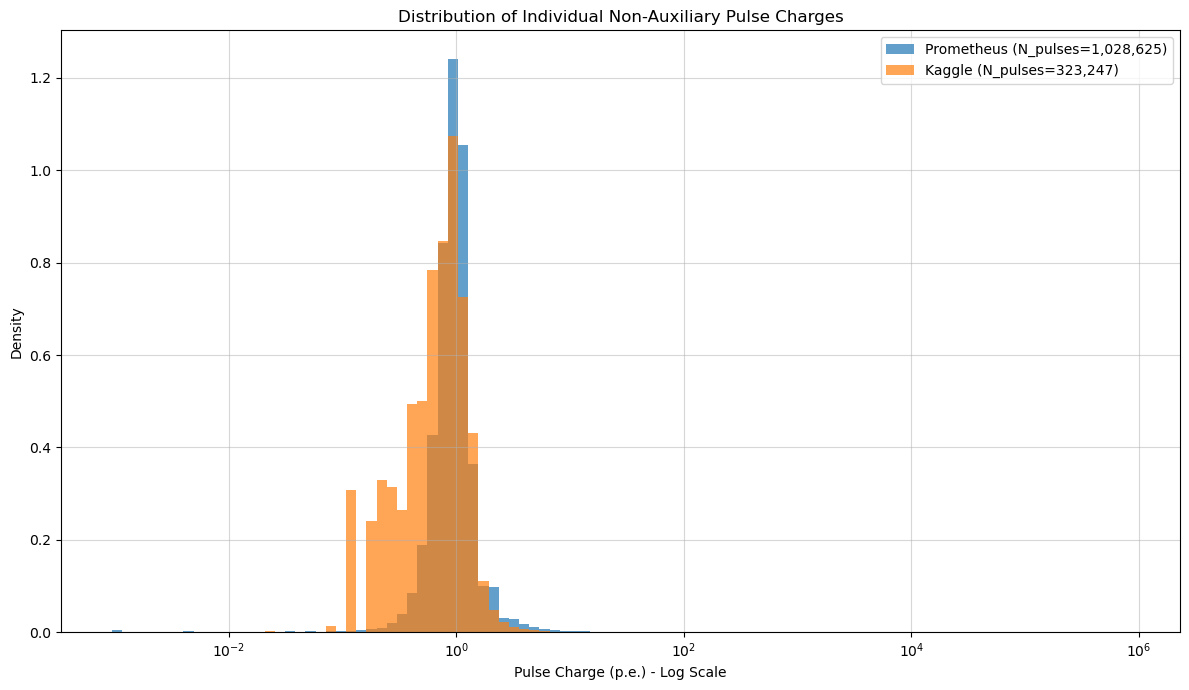

In [18]:
plot_pulse_charge_histograms(
    train_loader_p,
    val_loader_k,
    label1="Prometheus",
    label2="Kaggle",
    max_events=10000, # Example: Process 50k events from each loader
    num_bins=100
)

In [19]:
# Ensure these imports are done in your notebook
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D
import warnings
import math

# Ensure SPEED_OF_LIGHT_M_NS is defined
SPEED_OF_LIGHT_M_NS = 0.299792458

# Ensure charge_to_size is defined (using the corrected version)
def charge_to_size(charge, scale=5, min_size=5, max_size=300):
    charge_arr = np.asarray(charge)
    sizes = scale * np.log1p(charge_arr / 1.0) + min_size
    return np.clip(sizes, min_size, max_size)

# --- Updated visualize_event ---
def visualize_event(x_event_norm, l_event, sensor_geometry_df, title_prefix="Event"):
    """
    Generates side-by-side 3D event display and styled 2D light cone plot.
    Returns the matplotlib Figure object. Does NOT call plt.show().
    """
    # --- 1. Data Extraction and Processing ---
    # (Same as before: check length, denormalize, filter non-aux, get coords)
    if l_event <= 0: return None # Return None if no data
    valid_pulses_norm = x_event_norm[:l_event]
    try:
        raw_times = valid_pulses_norm[:, 0] * 3e4 + 1e4
        with np.errstate(over='ignore'): raw_charges = 10**(valid_pulses_norm[:, 1] * 3.0)
        raw_aux = valid_pulses_norm[:, 2] + 0.5
        raw_sensor_ids = (valid_pulses_norm[:, 3] - 1).astype(int)
    except Exception as e: print(f"{title_prefix}: Error denormalizing: {e}"); return None
    non_aux_mask = (np.round(raw_aux) == 0)
    if not np.any(non_aux_mask): return None # Return None if no non-aux
    # ... (rest of filtering/coord fetching identical to previous version) ...
    original_indices = np.arange(len(raw_times)); non_aux_indices_orig = original_indices[non_aux_mask]
    non_aux_times = raw_times[non_aux_mask]; non_aux_charges = raw_charges[non_aux_mask]; non_aux_sensors = raw_sensor_ids[non_aux_mask]
    coords = []; valid_pulse_indices_rel = []; original_pulse_indices = []
    for i, sensor_id in enumerate(non_aux_sensors):
        try: coords.append(sensor_geometry_df.loc[sensor_id, ['x', 'y', 'z']].values); valid_pulse_indices_rel.append(i); original_pulse_indices.append(non_aux_indices_orig[i])
        except KeyError: pass
    if not valid_pulse_indices_rel: return None
    valid_pulse_indices_rel = np.array(valid_pulse_indices_rel)
    coords_np = np.array(coords); times_np = non_aux_times[valid_pulse_indices_rel]; charges_np = non_aux_charges[valid_pulse_indices_rel]
    sensors_np = non_aux_sensors[valid_pulse_indices_rel]; original_indices_np = np.array(original_pulse_indices)
    charges_np = np.maximum(charges_np, 0); num_plotted_pulses = len(times_np)
    if num_plotted_pulses < 1: return None
    first_pulse_idx_in_valid = np.argmin(times_np)

    # --- Create Pulse Details Table (as before) ---
    pulse_data = []
    # ... (code to populate pulse_data list) ...
    for i in range(num_plotted_pulses):
        is_first = (i == first_pulse_idx_in_valid)
        pulse_data.append({
            "Plot Idx": i, "SensorID": sensors_np[i], "X": coords_np[i, 0], "Y": coords_np[i, 1], "Z": coords_np[i, 2],
            "Time": times_np[i], "Charge": charges_np[i], "Origin": "Yes" if is_first else ""
        })
    pulse_df = pd.DataFrame(pulse_data)
    formatted_pulse_table = pulse_df.to_string(index=False, formatters={ 'X': '{:7.1f}'.format, 'Y': '{:7.1f}'.format, 'Z': '{:7.1f}'.format, 'Time': '{:10.2f}'.format, 'Charge': '{:8.2f}'.format, 'SensorID': '{:5d}'.format, 'Plot Idx': '{:3d}'.format })


    # Determine consistent color/size mapping
    time_min, time_max = np.min(times_np), np.max(times_np)
    if time_min == time_max: time_max += 1
    norm = mcolors.Normalize(vmin=time_min, vmax=time_max)
    cmap = plt.cm.viridis
    sizes = charge_to_size(charges_np)

    # --- Setup Figure and Subplots ---
    fig = plt.figure(figsize=(18, 7)) # Adjusted figsize slightly
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax2 = fig.add_subplot(1, 2, 2)
    fig.suptitle(f"{title_prefix} ({num_plotted_pulses} non-aux pulses plotted)", fontsize=16, y=1.02) # Adjust title y pos

    # --- Plot 1: 3D Event Display (on ax1) ---
    # ... (ax1 plotting code identical to previous version) ...
    scatter_3d = ax1.scatter(coords_np[:, 0], coords_np[:, 1], coords_np[:, 2], c=times_np, cmap=cmap, norm=norm, s=sizes, alpha=0.7, label='Non-Aux Pulses')
    ax1.scatter(coords_np[first_pulse_idx_in_valid, 0], coords_np[first_pulse_idx_in_valid, 1], coords_np[first_pulse_idx_in_valid, 2], marker='*', s=max(150, sizes[first_pulse_idx_in_valid]*1.5), c='red', edgecolor='black', label='First Pulse (Origin)', depthshade=False, zorder=11)
    ax1.set_xlabel('X (m)'); ax1.set_ylabel('Y (m)'); ax1.set_zlabel('Z (m)'); ax1.set_title('3D Event Display'); ax1.set_xlim(-600, 600); ax1.set_ylim(-600, 600); ax1.set_zlim(-600, 600); ax1.legend(fontsize=9)

    # --- Plot 2: 2D Light Cone Plot (on ax2) ---
    # ... (calculation of x_plot, y_plot, limits identical) ...
    t0 = times_np[first_pulse_idx_in_valid]; coords0 = coords_np[first_pulse_idx_in_valid]
    delta_t = times_np - t0; delta_coords = coords_np - coords0; delta_d = np.linalg.norm(delta_coords, axis=1)
    x_plot = delta_d ; y_plot = delta_t * SPEED_OF_LIGHT_M_NS; pad = 50
    xlims = (-pad, np.max(x_plot) + pad); ylims = (min(-pad, np.min(y_plot) - pad) , np.max(y_plot) + pad)

    # ... (ax2 styling code identical - arrows, shading, cone lines) ...
    ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False); ax2.spines['left'].set_position(('data', xlims[0])); ax2.spines['bottom'].set_position(('data', ylims[0])); ax2.xaxis.set_ticks_position('bottom'); ax2.yaxis.set_ticks_position('left'); ax2.plot(xlims[1], ylims[0], ">k", ms=5, clip_on=False); ax2.plot(xlims[0], ylims[1], "^k", ms=5, clip_on=False); ax2.text(xlims[1], ylims[0] - (ylims[1]-ylims[0])*0.02, ' Spatial Distance (m)', ha='right', va='top'); ax2.text(xlims[0] - (xlims[1]-xlims[0])*0.02, ylims[1], ' c * Δt (m)', ha='right', va='bottom', rotation=90)
    x_fill = np.linspace(max(0, xlims[0]), xlims[1], 500); ax2.fill_between(x_fill, -x_fill, x_fill, where=x_fill>=0, color='grey', alpha=0.15, interpolate=True, label='Space-like Region (|c*Δt| < Δd)')
    diag_lim = max(abs(lim) for lim in list(xlims) + list(ylims)) * 1.1; ax2.plot([-diag_lim, diag_lim], [-diag_lim, diag_lim], 'k--', lw=1, alpha=0.5, label='Light Cone Boundary'); ax2.plot([-diag_lim, diag_lim], [diag_lim, -diag_lim], 'k--', lw=1, alpha=0.5)

    # ... (ax2 scatter plot identical) ...
    scatter_lc = ax2.scatter(x_plot, y_plot, c=times_np, cmap=cmap, norm=norm, s=sizes, alpha=0.8, zorder=10, label='Non-Aux Pulses')
    ax2.scatter(x_plot[first_pulse_idx_in_valid], y_plot[first_pulse_idx_in_valid], marker='*', s=max(150, sizes[first_pulse_idx_in_valid]*1.5), c='red', edgecolor='black', label='First Pulse (Origin)', zorder=11)
    ax2.set_title('Light Cone Plot (Origin at First Non-Aux Pulse)'); ax2.grid(True, alpha=0.3); ax2.legend(fontsize=9); ax2.set_xlim(xlims); ax2.set_ylim(ylims)

    # --- Add Colorbar (attached to ax2) ---
    # This usually places it reasonably next to the second plot
    cbar = fig.colorbar(scatter_lc, ax=ax2, shrink=0.9, aspect=20, pad=0.08) # Adjust shrink, aspect, pad
    cbar.set_label(f'Absolute Time (ns) [{int(time_min):,}, {int(time_max):,}]')

    # Adjust layout to prevent overlap (important!)
    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust rect to make space for suptitle

    # --- Return Figure and Pulse Table ---
    return fig, formatted_pulse_table

In [20]:
# --- Updated find_and_plot_event_categories ---
def find_and_plot_event_categories(dataloader, sensor_geometry_df, num_examples=1, max_batches_to_search=500):
    """
    Finds example events based on non-aux pulse count categories.
    Returns a dictionary containing the raw data for found events.
    """
    print("--- Searching for Example Events by Non-Aux Pulse Count ---")
    categories = {
        '< 20':      lambda count: count > 0 and count < 20,
        '20 <= M < 50': lambda count: count >= 20 and count < 50,
        '50 <= M < 100':lambda count: count >= 50 and count < 100,
        '>= 100':     lambda count: count >= 100,
    }
    found_events = {k: [] for k in categories}
    needed_count = {k: num_examples for k in categories}
    total_needed = sum(needed_count.values())
    total_found = 0
    batches_searched = 0

    # Try to estimate total batches for tqdm
    try:
        bs = 32 # Default guess
        if hasattr(dataloader, 'batch_size') and dataloader.batch_size is not None: bs = dataloader.batch_size
        elif hasattr(dataloader, 'sampler') and hasattr(dataloader.sampler, 'batch_size'): bs = dataloader.sampler.batch_size
        max_batches = max_batches_to_search if max_batches_to_search else len(dataloader)
    except TypeError: max_batches = max_batches_to_search

    pbar_find = tqdm(dataloader, total=max_batches, desc="Scanning batches", leave=False)
    for batch_num, batch in enumerate(pbar_find):
        if max_batches_to_search and batches_searched >= max_batches_to_search:
            print(f"Reached max search limit of {max_batches_to_search} batches.")
            break
        batches_searched += 1

        try: (x_batch_torch, l_batch_torch), _ = batch
        except ValueError as e: warnings.warn(f"Error unpacking batch {batch_num}: {e}. Skipping."); continue

        x_batch = x_batch_torch.cpu().numpy(); l_batch = l_batch_torch.cpu().numpy()
        batch_size = x_batch.shape[0]

        for event_idx in range(batch_size):
            l_event_raw = l_batch[event_idx]
            try: l_event = int(l_event_raw); assert l_event > 0
            except: continue

            x_event_norm = x_batch[event_idx]; valid_pulses_norm = x_event_norm[:l_event]
            try: raw_aux = valid_pulses_norm[:, 2] + 0.5
            except Exception: continue
            non_aux_mask = (np.round(raw_aux) == 0); num_non_aux = np.sum(non_aux_mask)

            for cat_name, condition_func in categories.items():
                if condition_func(num_non_aux):
                    if len(found_events[cat_name]) < needed_count[cat_name]:
                        print(f"Found event for category '{cat_name}' (Count: {num_non_aux}) - Batch {batch_num}, Idx {event_idx}")
                        # Store the necessary data
                        found_events[cat_name].append({
                            'x': x_event_norm.copy(), # Store raw normalized data
                            'l': l_event,
                            'id': f'Batch {batch_num}, Idx {event_idx}',
                            'count': num_non_aux
                        })
                        total_found += 1
                        pbar_find.set_postfix_str(f"Found {total_found}/{total_needed}")
                    break
            if total_found >= total_needed: break
        if total_found >= total_needed: break
    pbar_find.close()

    if total_found < total_needed: print(f"\nWarning: Finished search but only found {total_found}/{total_needed} examples.")
    print("--- Event Search Complete ---")
    return found_events

In [23]:
import ipywidgets as widgets
from IPython.display import display, clear_output


# --- Find the events ---
found_events_dict = find_and_plot_event_categories(
    train_loader_p, # Pass the dataloader to search
    sensor_geometry_df_orca, # Geometry needed only later for plotting
    num_examples=1, # Find 1 example per category
    max_batches_to_search=500 # Limit how many batches to check
)

# --- Create Accordion and Display Plots ---
accordion_children = []
accordion_titles = []

print("\n--- Generating visualizations in Accordion ---")

# Sort categories for consistent order
sorted_categories = sorted(found_events_dict.keys(), key=lambda x: {'<':0, '20':1, '50':2, '>':3}.get(x[0], 9))


for cat_name in sorted_categories:
    events_list = found_events_dict[cat_name]
    if not events_list:
        print(f"No event found for category: '{cat_name}'")
        continue

    # Create an Output widget for this category's plot(s)
    out = widgets.Output()
    accordion_children.append(out)
    # Create title including pulse count
    event_data = events_list[0] # Using the first found example
    title = f"{cat_name} ({event_data['count']} non-aux) - {event_data['id']}"
    accordion_titles.append(title)

    # Display the plot and table inside the Output widget
    with out:
        print(f"Generating plot for: {title}")
        # Call visualize_event to get the figure and table string
        fig, pulse_table_str = visualize_event(
            event_data['x'],
            event_data['l'],
            sensor_geometry_df_orca,
            title_prefix=title # Use detailed title for the plot too
        )

        if fig is not None:
            # Display the matplotlib figure in the output widget
            display(fig)
            # IMPORTANT: Close the plot to free memory and prevent double display
            plt.close(fig)
            # Print the pulse table string
            print("\n--- Plotted Non-Auxiliary Pulse Details ---")
            print(pulse_table_str)
            print("-"*(len(pulse_table_str.split('\n')[0])))
        else:
            print("Failed to generate visualization for this event.")

# Create and display the Accordion
if accordion_children:
    accordion = widgets.Accordion(children=tuple(accordion_children))
    for i, title in enumerate(accordion_titles):
        accordion.set_title(i, title)
    print("\nDisplaying Accordion (click titles to expand/collapse):")
    display(accordion)
else:
    print("\nNo events found to display in Accordion.")

--- Searching for Example Events by Non-Aux Pulse Count ---


Scanning batches:   0%|          | 0/500 [00:00<?, ?it/s]

Found event for category '50 <= M < 100' (Count: 80) - Batch 0, Idx 0
Found event for category '>= 100' (Count: 127) - Batch 0, Idx 1
Found event for category '< 20' (Count: 5) - Batch 0, Idx 2
Found event for category '20 <= M < 50' (Count: 29) - Batch 0, Idx 6
--- Event Search Complete ---

--- Generating visualizations in Accordion ---



Displaying Accordion (click titles to expand/collapse):


Accordion(children=(Output(), Output(), Output(), Output()), titles=('< 20 (5 non-aux) - Batch 0, Idx 2', '>= …

In [22]:
import ipywidgets as widgets
from IPython.display import display, clear_output


# --- Find the events ---
found_events_dict = find_and_plot_event_categories(
    train_loader_k, # Pass the dataloader to search
    sensor_geometry_df, # Geometry needed only later for plotting
    num_examples=1, # Find 1 example per category
    max_batches_to_search=500 # Limit how many batches to check
)

# --- Create Accordion and Display Plots ---
accordion_children = []
accordion_titles = []

print("\n--- Generating visualizations in Accordion ---")

# Sort categories for consistent order
sorted_categories = sorted(found_events_dict.keys(), key=lambda x: {'<':0, '20':1, '50':2, '>':3}.get(x[0], 9))


for cat_name in sorted_categories:
    events_list = found_events_dict[cat_name]
    if not events_list:
        print(f"No event found for category: '{cat_name}'")
        continue

    # Create an Output widget for this category's plot(s)
    out = widgets.Output()
    accordion_children.append(out)
    # Create title including pulse count
    event_data = events_list[0] # Using the first found example
    title = f"{cat_name} ({event_data['count']} non-aux) - {event_data['id']}"
    accordion_titles.append(title)

    # Display the plot and table inside the Output widget
    with out:
        print(f"Generating plot for: {title}")
        # Call visualize_event to get the figure and table string
        fig, pulse_table_str = visualize_event(
            event_data['x'],
            event_data['l'],
            sensor_geometry_df,
            title_prefix=title # Use detailed title for the plot too
        )

        if fig is not None:
            # Display the matplotlib figure in the output widget
            display(fig)
            # IMPORTANT: Close the plot to free memory and prevent double display
            plt.close(fig)
            # Print the pulse table string
            print("\n--- Plotted Non-Auxiliary Pulse Details ---")
            print(pulse_table_str)
            print("-"*(len(pulse_table_str.split('\n')[0])))
        else:
            print("Failed to generate visualization for this event.")

# Create and display the Accordion
if accordion_children:
    accordion = widgets.Accordion(children=tuple(accordion_children))
    for i, title in enumerate(accordion_titles):
        accordion.set_title(i, title)
    print("\nDisplaying Accordion (click titles to expand/collapse):")
    display(accordion)
else:
    print("\nNo events found to display in Accordion.")

--- Searching for Example Events by Non-Aux Pulse Count ---


Scanning batches:   0%|          | 0/500 [00:00<?, ?it/s]

Found event for category '< 20' (Count: 8) - Batch 0, Idx 0
Found event for category '20 <= M < 50' (Count: 38) - Batch 0, Idx 3
Found event for category '>= 100' (Count: 127) - Batch 0, Idx 19
Found event for category '50 <= M < 100' (Count: 89) - Batch 0, Idx 27
--- Event Search Complete ---

--- Generating visualizations in Accordion ---



Displaying Accordion (click titles to expand/collapse):


Accordion(children=(Output(), Output(), Output(), Output()), titles=('< 20 (8 non-aux) - Batch 0, Idx 0', '>= …